In [7]:
import pandas as pd
import numpy as np
df=pd.read_csv("student_data.csv")
df.head()

,study_hours,attendance,internal_score,sleep_hours,screen_time,practice_tests,final_score
0,5.25,84.9,16.8,6.75,4.21,11.0,86.6
1,4.29,61.9,24.7,8.50,4.83,13.0,97.5
2,5.47,73.3,23.5,4.35,4.48,17.0,94.0
3,6.78,88.9,18.2,8.09,4.11,15.0,100.0
4,4.15,78.6,19.9,8.25,4.78,13.0,84.8


In [8]:
print(df.shape)

(222, 7)


In [9]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 222 entries, 0 to 221
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   study_hours     222 non-null    float64
 1   attendance      222 non-null    float64
 2   internal_score  222 non-null    float64
 3   sleep_hours     222 non-null    float64
 4   screen_time     222 non-null    float64
 5   practice_tests  222 non-null    float64
 6   final_score     222 non-null    float64
dtypes: float64(7)
memory usage: 12.3 KB
None


In [10]:
df.isnull().sum()

study_hours       0
attendance        0
internal_score    0
sleep_hours       0
screen_time       0
practice_tests    0
final_score       0
dtype: int64

In [11]:
df.duplicated().sum()




0

In [12]:
numeric_cols = df.select_dtypes(include=np.number).columns
print(numeric_cols)



Index(['study_hours', 'attendance', 'internal_score', 'sleep_hours',
       'screen_time', 'practice_tests', 'final_score'],
      dtype='object')


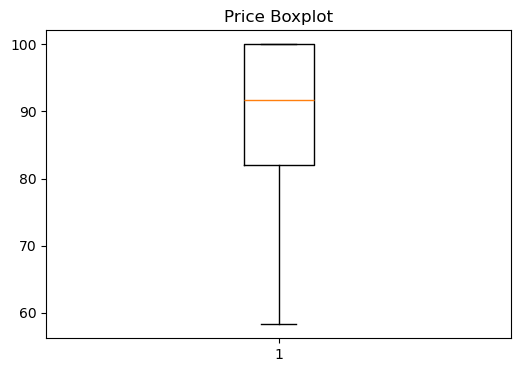

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.boxplot(df["final_score"])
plt.title("Price Boxplot")
plt.show()


In [15]:
upper_limit = df["final_score"].quantile(0.99)

df_clean = df[df["final_score"] <= upper_limit]

print("Original Shape:", df.shape)
print("After Removing Top 1%:", df_clean.shape)


Original Shape: (222, 7)
After Removing Top 1%: (222, 7)


In [16]:
import numpy as np

df["final_score"] = np.log1p(df["final_score"])


In [17]:
X = df.drop("final_score", axis=1)
y = df["final_score"]


In [18]:
X.select_dtypes(include="object").columns




Index([], dtype='object')

In [19]:
import pandas as pd
from sklearn.model_selection import train_test_split

# ---------------- LOAD DATA ----------------
df = pd.read_csv("student_data.csv")

# ---------------- FEATURES & TARGET ----------------
X = df.drop("final_score", axis=1)   # Input features
y = df["final_score"]                # Target variable

# ---------------- TRAIN TEST SPLIT ----------------
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,      # 80% training, 20% testing
    random_state=42     # Ensures reproducibility
)

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

Training Data Shape: (177, 6)
Testing Data Shape: (45, 6)


In [22]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X, y)



LinearRegression()

In [23]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)  # Fit ONLY on training
X_test_scaled = scaler.transform(X_test)        # Transform test

In [24]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train_scaled, y_train)

LinearRegression()

In [25]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

# Predictions
y_pred = model.predict(X_test_scaled)

# Metrics
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("R2 Score :", r2)
print("MAE      :", mae)
print("RMSE     :", rmse)

R2 Score : 0.7871252102127744
MAE      : 3.9126025802676168
RMSE     : 4.849776988733959


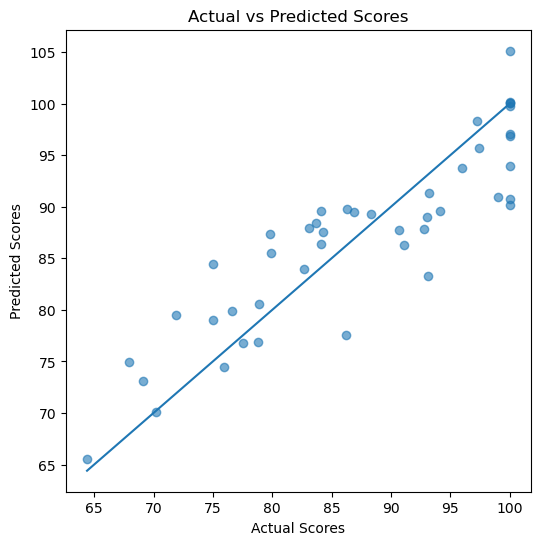

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))

plt.scatter(y_test, y_pred, alpha=0.6)

# Perfect prediction line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()]
)

plt.xlabel("Actual Scores")
plt.ylabel("Predicted Scores")
plt.title("Actual vs Predicted Scores")

plt.show()

In [27]:
import joblib

joblib.dump(model, "student_model.pkl")
joblib.dump(scaler, "scaler.pkl")

print("Model saved successfully ✅")

Model saved successfully ✅
